In [1]:
# Import pandas for handling dataset
import pandas as pd

# Import matplotlib for charts
import matplotlib.pyplot as plt

# Split dataset into training/testing
from sklearn.model_selection import train_test_split

# Import Decision Tree model
from sklearn.tree import DecisionTreeClassifier

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [2]:
# Load dataset from CSV file
df = pd.read_csv("dataset.csv")

# Display first 5 rows
df.head()

,fever,headache,cough,fatigue,body pain,sore throat,chest pain,shortness of breath,vomiting,diarrhea,...,ear pain,eye redness,blurred vision,palpitations,anxiety,loss of appetite,weight loss,swelling,dry mouth,disease
0,1,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Flu
1,1,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Flu
2,1,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Flu
3,1,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Flu
4,1,0,1,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Flu


In [3]:
# Show dataset size
print("Dataset shape:", df.shape)

# Show samples per disease
print("\nDisease counts:")
print(df["disease"].value_counts())

Dataset shape: (360, 31)

Disease counts:
disease
Flu                        20
Common Cold                20
COVID-19                   20
Migraine                   20
Food Poisoning             20
Gastritis                  20
Respiratory Issue          20
Allergy                    20
Urinary Tract Infection    20
Joint Inflammation         20
Asthma                     20
Bronchitis                 20
Pneumonia                  20
Eczema                     20
Skin Infection             20
Vertigo                    20
Possible Cardiac Issue     20
Kidney Stone               20
Name: count, dtype: int64


In [4]:
# X = symptom columns
X = df.drop("disease", axis=1)

# y = disease column
y = df["disease"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (360, 30)
Target shape: (360,)


In [5]:
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (288, 30)
Testing size: (72, 30)


In [6]:
# Create Decision Tree model
# max_depth limits the tree size to reduce overfitting
# class_weight='balanced' helps treat all diseases fairly

dt_model = DecisionTreeClassifier(
    max_depth=8,
    class_weight="balanced",
    random_state=42
)

# Train model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [7]:
# Predict diseases using testing data
y_pred = dt_model.predict(X_test)

print("Prediction completed.")

Prediction completed.


In [8]:
# Calculate model performance
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Decision Tree Results")
print("---------------------")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

Decision Tree Results
---------------------
Accuracy: 0.4167
Precision: 0.4447
Recall: 0.4167
F1-score: 0.3859


In [9]:
# Detailed results for each disease
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

                         precision    recall  f1-score   support

                Allergy       0.67      0.50      0.57         4
                 Asthma       0.11      1.00      0.19         4
             Bronchitis       0.00      0.00      0.00         4
               COVID-19       0.00      0.00      0.00         4
            Common Cold       0.50      0.25      0.33         4
                 Eczema       0.60      0.75      0.67         4
                    Flu       0.67      0.50      0.57         4
         Food Poisoning       1.00      0.50      0.67         4
              Gastritis       0.00      0.00      0.00         4
     Joint Inflammation       1.00      1.00      1.00         4
           Kidney Stone       0.67      1.00      0.80         4
               Migraine       0.80      1.00      0.89         4
              Pneumonia       0.00      0.00      0.00         4
 Possible Cardiac Issue       1.00      0.75      0.86         4
      Respiratory Issue 

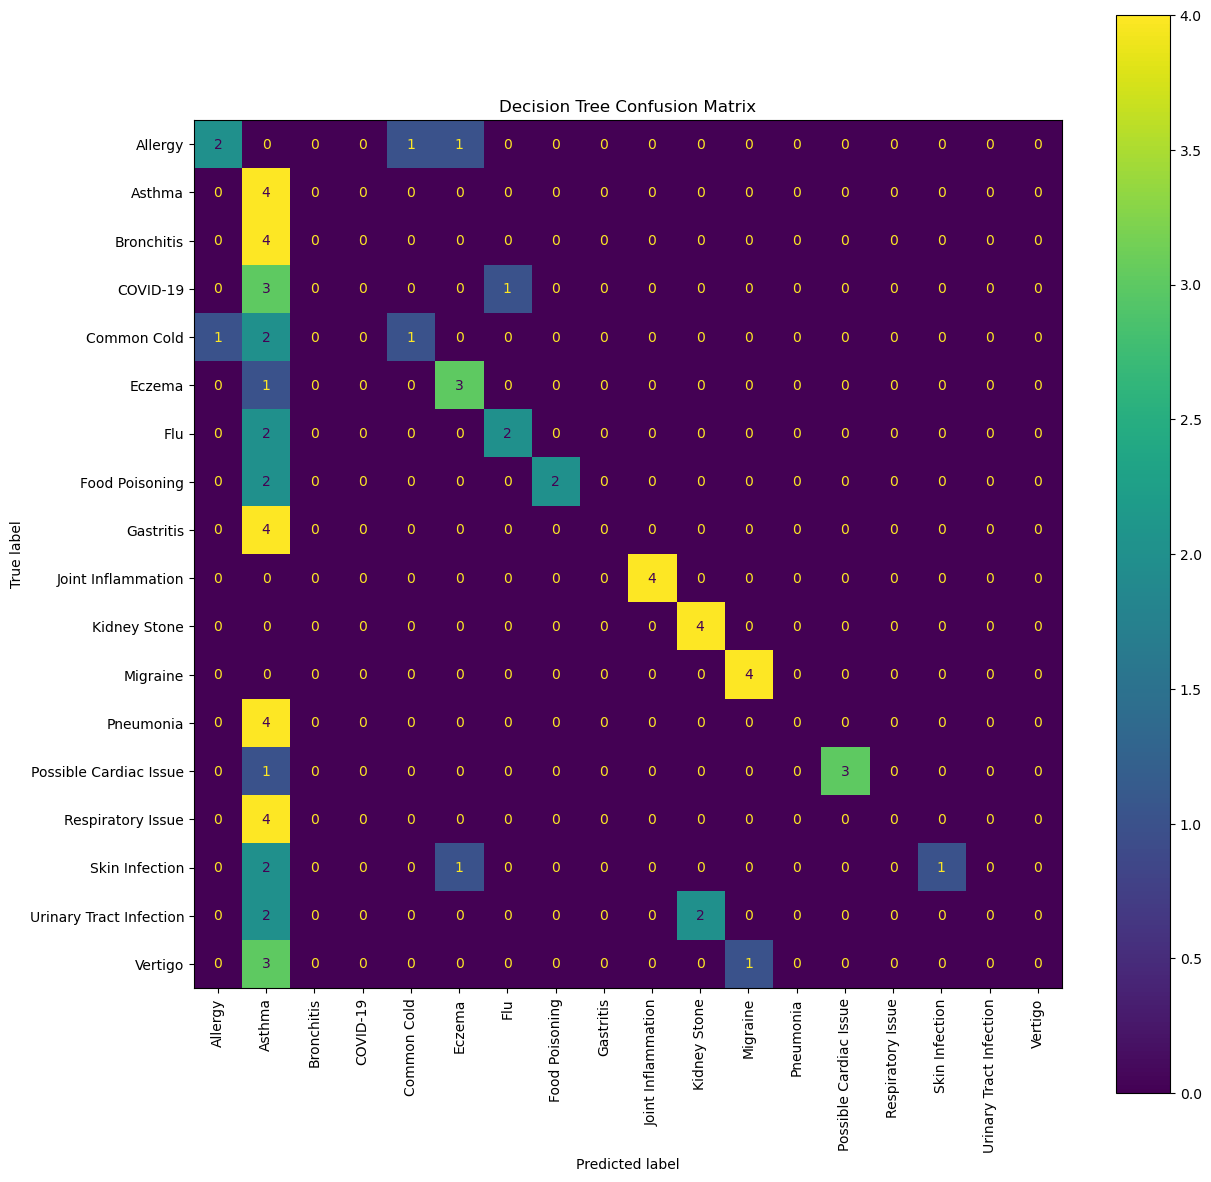

In [10]:
# Create confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=dt_model.classes_
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dt_model.classes_
)

fig, ax = plt.subplots(figsize=(14, 14))

disp.plot(ax=ax, xticks_rotation=90)

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [11]:
# Store Decision Tree results for final comparison
decision_tree_results = {
    "Model": "Decision Tree",
    "Accuracy": round(accuracy, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1-score": round(f1, 4)
}

decision_tree_results

{'Model': 'Decision Tree',
 'Accuracy': 0.4167,
 'Precision': 0.4447,
 'Recall': 0.4167,
 'F1-score': 0.3859}